# Regression — End-to-End ML Pipeline (Practical Implementation)

> A complete, beginner-friendly walkthrough of the full Machine Learning pipeline for regression problems, with clear explanations for every cell, visual plots, multiple algorithms, tuning, and two real end-to-end projects.

---

## What You Will Learn

This notebook follows the **standard ML pipeline** step by step:

```
┌──────────────┐   ┌──────────┐   ┌─────────────┐   ┌─────────────────┐
│ 1. Problem   │──▶│ 2. Data  │──▶│ 3. EDA &    │──▶│ 4. Data Cleaning│
│   Framing    │   │ Loading  │   │ Visualize   │   │ & Preprocessing │
└──────────────┘   └──────────┘   └─────────────┘   └─────────────────┘
                                                             │
        ┌────────────────────────────────────────────────────┘
        ▼
┌─────────────────┐   ┌──────────────┐   ┌─────────────┐   ┌──────────────┐
│ 5. Feature      │──▶│ 6. Train/    │──▶│ 7. Model    │──▶│ 8. Evaluate  │
│    Engineering  │   │   Test Split │   │   Training  │   │   Metrics    │
└─────────────────┘   └──────────────┘   └─────────────┘   └──────────────┘
                                                                 │
        ┌────────────────────────────────────────────────────────┘
        ▼
┌─────────────────┐   ┌──────────────┐   ┌─────────────┐
│ 9. Hyperparam   │──▶│ 10. Compare  │──▶│ 11. Deploy  │
│    Tuning + CV  │   │ & Interpret  │   │  / Predict  │
└─────────────────┘   └──────────────┘   └─────────────┘
```

---

## Table of Contents

| # | Section |
|---|---------|
| 0 | ML Pipeline Overview |
| 1 | Setup — Imports |
| 2 | Data Loading + EDA + Visualizations |
| 3 | Data Cleaning & Manipulation |
| 4 | Feature Engineering |
| 5 | Feature Selection (Filter / Wrapper / Embedded) |
| 6 | Train/Test Split + Scaling |
| 7 | Regression Algorithms (11 models) |
| 8 | Evaluation Metrics in Depth |
| 9 | All-Model Comparison Table + Charts |
| 10 | Cross-Validation |
| 11 | Hyperparameter Tuning (GridSearchCV + RandomizedSearchCV) |
| 12 | **Project 1 — House Price Prediction (end-to-end)** |
| 13 | **Project 2 — Insurance Claim Recovery (end-to-end)** |
| 14 | Summary + What To Try Next |

---

### Which of the listed projects are regression?

| Project | Type | Covered here? |
|---------|------|---------------|
| House Price Prediction | **Regression** | ✅ Project 1 |
| Customer Churn Prediction | Classification | ❌ (goes in classification notebook) |
| Credit Risk Model | Classification | ❌ |
| Insurance Claim Recovery | **Regression** | ✅ Project 2 |
| Fraud Detection | Classification | ❌ |
| Recommendation System | Ranking / Hybrid | ❌ |


---
# 0. ML Pipeline — Quick Overview

A regression project always follows the same steps. Understanding this flow is more important than memorizing any single algorithm.

| Step | Purpose | Tools we use |
|------|---------|--------------|
| 1. Frame the problem | What are we predicting? What error is acceptable? | — |
| 2. Load data | Read CSV / DB / API | `pandas` |
| 3. EDA | Shape, types, nulls, distributions, correlations | `pandas`, `matplotlib`, `seaborn` |
| 4. Cleaning | Handle missing values, outliers, wrong types | `pandas` |
| 5. Feature engineering | Create/transform features | `pandas`, `sklearn.preprocessing` |
| 6. Feature selection | Drop irrelevant features | `SelectKBest`, `RFE`, Lasso |
| 7. Split | Train / Test (or Train / Val / Test) | `train_test_split` |
| 8. Scale | Put features on same scale | `StandardScaler` |
| 9. Train models | Try several algorithms | `sklearn`, `xgboost` |
| 10. Evaluate | Pick a metric, compare models | `MAE`, `RMSE`, `R²` |
| 11. Tune | Find best hyperparameters | `GridSearchCV`, `RandomizedSearchCV` |
| 12. Cross-validate | Check stability | `KFold`, `cross_val_score` |
| 13. Interpret | Feature importances, residuals | coef_, permutation_importance |
| 14. Save / Deploy | Persist model | `joblib` |


---
# 1. Setup — Imports

All libraries we'll need. Run this cell **first** — every later cell depends on these imports.


In [1]:
# ── 1. Setup: imports & config ─────────────────────────────────────────────
import warnings                                 # to silence harmless warnings
warnings.filterwarnings('ignore')               # keep the notebook output clean

import ssl                                      # macOS sometimes fails SSL for sklearn datasets
ssl._create_default_https_context = ssl._create_unverified_context

import numpy as np                              # numerical arrays & math
import pandas as pd                             # dataframes for tabular data
import matplotlib.pyplot as plt                 # basic plotting
import seaborn as sns                           # prettier statistical plots

# ── sklearn: data, preprocessing, models, metrics ────────────────────────
from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# ── Regression models ─────────────────────────────────────────────────────
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.svm import SVR
from xgboost import XGBRegressor                # XGBoost = external, very popular

# ── Metrics ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

# ── Feature selection ─────────────────────────────────────────────────────
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression, RFE
)

# ── Make output reproducible ──────────────────────────────────────────────
np.random.seed(42)                              # fix randomness
sns.set_style('whitegrid')                      # consistent seaborn look
plt.rcParams['figure.figsize'] = (10, 5)        # default figure size

print('All libraries imported ✔')


All libraries imported ✔


### Code Explanation — Setup

| Line | What it does | Why needed |
|------|--------------|------------|
| `warnings.filterwarnings('ignore')` | Mutes deprecation / convergence warnings | Keeps output readable |
| `ssl._create_default_https_context = ...` | Bypasses SSL verification for sklearn dataset downloads | Fix for macOS SSL cert errors |
| `import numpy as np` | Numerical arrays | All math / array ops |
| `import pandas as pd` | DataFrames | Tabular data handling |
| `import matplotlib.pyplot as plt` | Plotting | Base charts |
| `import seaborn as sns` | Statistical plots | Prettier plots on top of matplotlib |
| `fetch_california_housing` | Downloads California Housing dataset (20640 rows, 8 features) | Our primary regression dataset |
| `make_regression` | Generates a synthetic regression dataset | Used later for feature-selection demo |
| `train_test_split` | Splits data into train + test | Standard evaluation setup |
| `StandardScaler` | Zero-mean / unit-variance scaling | Required for linear models, KNN, SVR |
| `Pipeline` / `ColumnTransformer` | Chain preprocessing + model into one object | Prevents data leakage, clean code |
| `SimpleImputer` | Fills missing values | Used in cleaning |
| `LinearRegression / Ridge / Lasso / ElasticNet` | Linear family | Core regression models |
| `KNeighborsRegressor` | Distance-based prediction | Non-linear baseline |
| `DecisionTreeRegressor` | Single tree | Captures non-linear relationships |
| `RandomForest / GradientBoosting` | Tree ensembles | Strong general-purpose models |
| `SVR` | Support Vector Regression | Kernel method — non-linear |
| `XGBRegressor` | Gradient boosting — fast & accurate | Usually the strongest baseline |
| `SelectKBest`, `RFE` | Feature-selection helpers | Used in Section 5 |
| `np.random.seed(42)` | Fixes random number generator | Reproducible results |


---
# 2. Data Loading + Exploratory Data Analysis (EDA)

**Dataset:** California Housing (built into sklearn — no download needed).
**Target:** median house price (in $100,000s) for California districts.
**Features:** 8 numerical features about each district.

### Goal of EDA
Before modeling, we always ask:
1. What is the **shape** of the data?
2. Are there **missing values**?
3. What **type** is each column?
4. How is the **target distributed**?
5. Which features are **correlated** with the target?
6. Are there obvious **outliers**?


In [2]:
# ── 2a. Load the dataset ───────────────────────────────────────────────────
housing = fetch_california_housing()                                # downloads/loads
X = pd.DataFrame(housing.data, columns=housing.feature_names)       # features DataFrame
y = pd.Series(housing.target, name='MedHouseVal')                   # target Series

# quick sanity check
print(f'Feature matrix shape: {X.shape}')        # (rows, cols)
print(f'Target vector shape : {y.shape}')
print(f'Feature names       : {list(X.columns)}')
print(f'Target name         : {y.name}  (units: $100,000)')
X.head()                                          # first 5 rows


Feature matrix shape: (20640, 8)
Target vector shape : (20640,)
Feature names       : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target name         : MedHouseVal  (units: $100,000)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### Code Explanation — Loading Data

| Line | What it does |
|------|--------------|
| `fetch_california_housing()` | Returns a Bunch (like a dict) with `.data`, `.target`, `.feature_names` |
| `pd.DataFrame(..., columns=...)` | Wraps the NumPy array in a DataFrame so we can use column names |
| `pd.Series(..., name='MedHouseVal')` | Wraps target in a Series with a name |
| `X.shape` | Returns `(rows, columns)` — a basic sanity check |
| `X.head()` | Shows the first 5 rows — a quick look at the data |

**Features:**
- `MedInc`    — median income of the district
- `HouseAge`  — median age of houses
- `AveRooms`  — avg rooms per house
- `AveBedrms` — avg bedrooms per house
- `Population`— total population of district
- `AveOccup`  — avg household occupants
- `Latitude`, `Longitude` — district location


In [3]:
# ── 2b. Data types & missing values ────────────────────────────────────────
print('--- Data types ---')
print(X.dtypes)                      # column → dtype (all float64 here)

print('\n--- Missing values per column ---')
print(X.isnull().sum())              # 0 everywhere = clean dataset

print(f'\n--- Duplicates ---')
print(f'Duplicate rows: {X.duplicated().sum()}')


--- Data types ---
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object

--- Missing values per column ---
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

--- Duplicates ---
Duplicate rows: 0


### Code Explanation
- `X.dtypes` — one row per column, shows the stored type. All numeric → easy to scale / model.
- `X.isnull().sum()` — counts NaNs per column. Anything > 0 would need imputation.
- `X.duplicated().sum()` — counts exact duplicate rows. Duplicates can bias training.


In [44]:
# ── 2c. Summary statistics ─────────────────────────────────────────────────
X.describe().round(2)                # count, mean, std, min, 25%, 50%, 75%, max


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31


### Code Explanation — `describe()`
- Shows **central tendency** (mean, median) and **spread** (std, min/max).
- Gaps between `mean` and `50%` (median) hint at **skew**.
- Big `max` values vs `75%` → possible **outliers** (e.g. AveRooms max is huge).


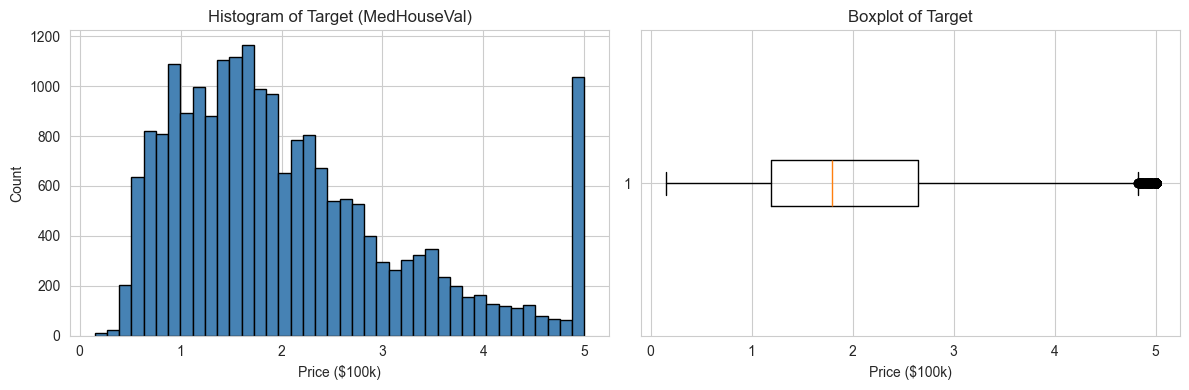

Target mean  : 2.07  (≈ $206,856)
Target median: 1.80  (≈ $179,700)
Target max   : 5.00  (≈ $500,001)  ← capped at 5.0 = $500k


In [4]:
# ── 2d. Target distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram — shape of the distribution
axes[0].hist(y, bins=40, color='steelblue', edgecolor='black')
axes[0].set(title='Histogram of Target (MedHouseVal)', xlabel='Price ($100k)', ylabel='Count')

# boxplot — see outliers & spread
axes[1].boxplot(y, vert=False)
axes[1].set(title='Boxplot of Target', xlabel='Price ($100k)')

plt.tight_layout();  plt.show()

print(f'Target mean  : {y.mean():.2f}  (≈ ${y.mean()*100_000:,.0f})')
print(f'Target median: {y.median():.2f}  (≈ ${y.median()*100_000:,.0f})')
print(f'Target max   : {y.max():.2f}  (≈ ${y.max()*100_000:,.0f})  ← capped at 5.0 = $500k')


### Code Explanation — Target plots

| Chart | What to look for |
|-------|------------------|
| Histogram | Is it normal? skewed? A **right-skewed** target often benefits from `log(y)` transform |
| Boxplot | Whiskers show the IQR range; dots past the whiskers are outliers |

**Key finding:** The target is **capped at 5.0** — the dataset creators clipped values ≥ $500k. This is a real-world artifact you would handle differently in production.


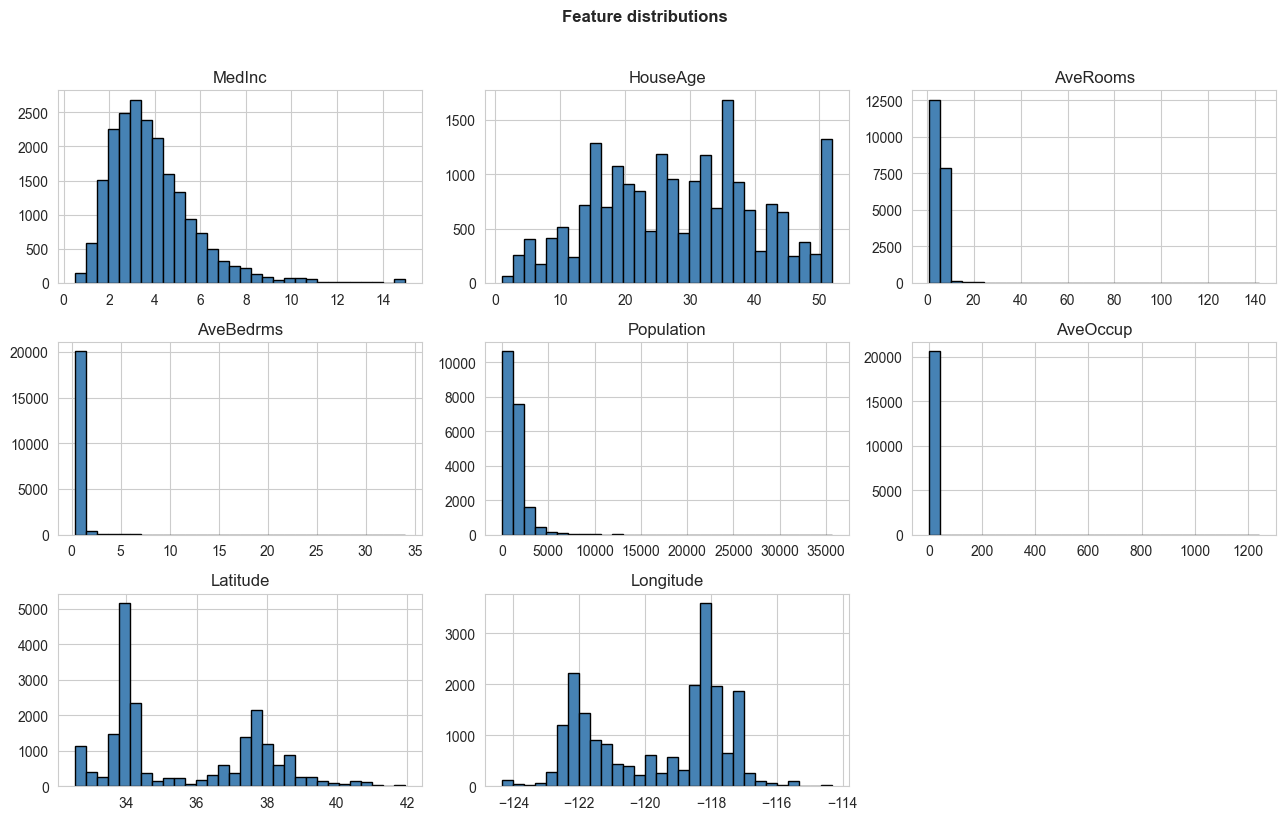

In [5]:
# ── 2e. Feature distributions ──────────────────────────────────────────────
X.hist(bins=30, figsize=(13, 8), color='steelblue', edgecolor='black')
plt.suptitle('Feature distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Code Explanation
- `X.hist(bins=30, ...)` — one histogram per numeric column.
- Look for:
  - **Heavily skewed** features (AveRooms, AveBedrms, Population) — may need `log1p` transform
  - **Bimodal** distributions (Latitude / Longitude — reflects northern vs southern California)
  - Columns with a **narrow range** — may already be scaled


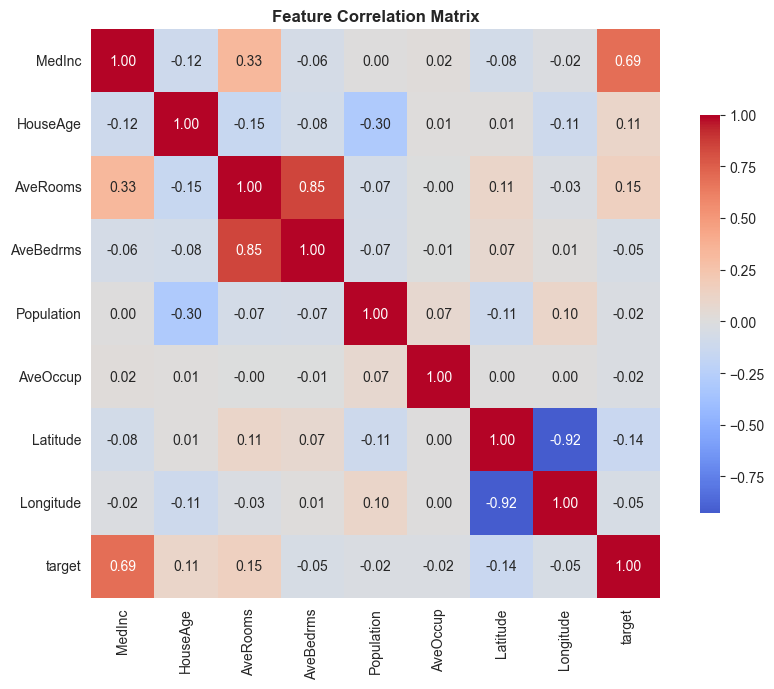

Correlation with target (sorted):
MedInc        0.688
AveRooms      0.152
HouseAge      0.106
AveOccup     -0.024
Population   -0.025
Longitude    -0.046
AveBedrms    -0.047
Latitude     -0.144
Name: target, dtype: float64


In [6]:
# ── 2f. Correlation heatmap ────────────────────────────────────────────────
df_full = X.copy()
df_full['target'] = y

corr = df_full.corr()                                      # Pearson correlations
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'shrink': .7})
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout();  plt.show()

# top features most correlated with target
print('Correlation with target (sorted):')
print(corr['target'].drop('target').sort_values(ascending=False).round(3))


### Code Explanation — Correlation

| Thing | Meaning |
|-------|---------|
| `df.corr()` | Pearson correlation matrix: range −1 … +1 |
| `+1` | Features move together perfectly |
| `0` | No linear relationship |
| `-1` | Features move opposite perfectly |
| Values > 0.8 | **Multicollinearity** — consider dropping or using Ridge |
| High `|corr with target|` | Likely an important predictor |

**Finding:** `MedInc` has the strongest correlation with price — rich districts have pricier houses.


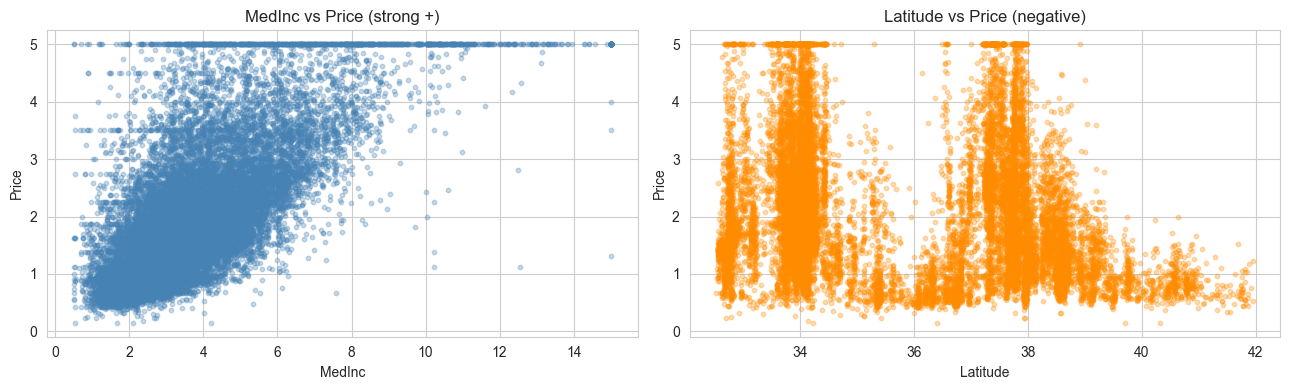

In [7]:
# ── 2g. Scatter: top feature vs target ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(X['MedInc'], y, alpha=0.3, s=10, color='steelblue')
axes[0].set(xlabel='MedInc', ylabel='Price', title='MedInc vs Price (strong +)')

axes[1].scatter(X['Latitude'], y, alpha=0.3, s=10, color='darkorange')
axes[1].set(xlabel='Latitude', ylabel='Price', title='Latitude vs Price (negative)')

plt.tight_layout();  plt.show()


### Code Explanation
- Scatter plots reveal the **shape** of the relationship (linear? curved? clustered?).
- `MedInc vs Price`: clear upward trend → Linear Regression should work.
- `Latitude vs Price`: horizontal bands at ~34° (LA) and ~38° (Bay Area) → expensive coastal clusters → **tree models** will capture this better than a line.


---
# 3. Data Cleaning & Manipulation

Our dataset is already clean — no missing values, no duplicates. So we will:
1. Demonstrate how to handle missing values (by injecting some)
2. Detect and cap outliers
3. Show common pandas manipulation tricks


In [8]:
# ── 3a. Injecting missing values (just to demo handling) ──────────────────
X_dirty = X.copy()                                             # never mutate original
rng = np.random.default_rng(42)

# randomly turn ~5% of HouseAge cells into NaN
mask = rng.random(len(X_dirty)) < 0.05                          # boolean mask
X_dirty.loc[mask, 'HouseAge'] = np.nan

print(f'Missing in HouseAge now: {X_dirty["HouseAge"].isnull().sum()}')


Missing in HouseAge now: 1028


### Code Explanation
- `X.copy()` — deep copy so the original stays untouched.
- `rng.random(n) < 0.05` — boolean mask with ~5% `True`.
- `.loc[mask, 'col'] = np.nan` — writes NaN where mask is True.


In [9]:
# ── 3b. Three ways to handle missing values ───────────────────────────────
# (1) Drop rows with any NaN
dropped = X_dirty.dropna()
print(f'After dropna: {dropped.shape[0]} rows (lost {len(X_dirty)-len(dropped)})')

# (2) Fill with mean (simple)
X_mean = X_dirty.copy()
X_mean['HouseAge'] = X_mean['HouseAge'].fillna(X_mean['HouseAge'].mean())

# (3) Use SimpleImputer (preferred — fits into Pipeline)
imputer = SimpleImputer(strategy='median')                      # median is robust to outliers
X_imputed = pd.DataFrame(imputer.fit_transform(X_dirty), columns=X.columns)
print(f'After imputer: missing = {X_imputed.isnull().sum().sum()}')


After dropna: 19612 rows (lost 1028)
After imputer: missing = 0


### Code Explanation — Handling Missing Values

| Method | When to use | Downside |
|--------|-------------|----------|
| `dropna()` | Very few rows have NaN | Loses data |
| `fillna(mean)` | Quick default | Distorts variance |
| `fillna(median)` | Numeric + outliers present | Slightly biased |
| `SimpleImputer` | Any pipeline use | Same as above but cleanly integrates with sklearn |
| `KNNImputer` | Complex patterns | Slow on big data |

**Rule of thumb:**
- < 5% missing → impute
- 5–40% missing → impute + add a missingness indicator column
- \> 40% missing → consider dropping the column


In [10]:
# ── 3c. Outlier detection using IQR ────────────────────────────────────────
def iqr_bounds(series, k=1.5):
    '''Return lower/upper bounds using the IQR rule.'''
    q1 = series.quantile(0.25)                    # 25th percentile
    q3 = series.quantile(0.75)                    # 75th percentile
    iqr = q3 - q1                                 # interquartile range
    return q1 - k * iqr, q3 + k * iqr

for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
    lo, hi = iqr_bounds(X[col])
    n_out = ((X[col] < lo) | (X[col] > hi)).sum()
    print(f'{col:12s}  bounds=({lo:8.2f}, {hi:10.2f})  outliers={n_out}')


AveRooms      bounds=(    2.02,       8.47)  outliers=511
AveBedrms     bounds=(    0.87,       1.24)  outliers=1424
AveOccup      bounds=(    1.15,       4.56)  outliers=711
Population    bounds=( -620.00,    3132.00)  outliers=1196


### Code Explanation — IQR Outlier Detection

- **IQR rule**: anything below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` is a potential outlier.
- `k=1.5` → standard threshold.  `k=3.0` → only "extreme" outliers.
- **You don't always remove outliers** — they may be real. Instead:
  - **Cap** them (winsorization)
  - Use **robust models** (tree-based, Huber)
  - **Log-transform** skewed features


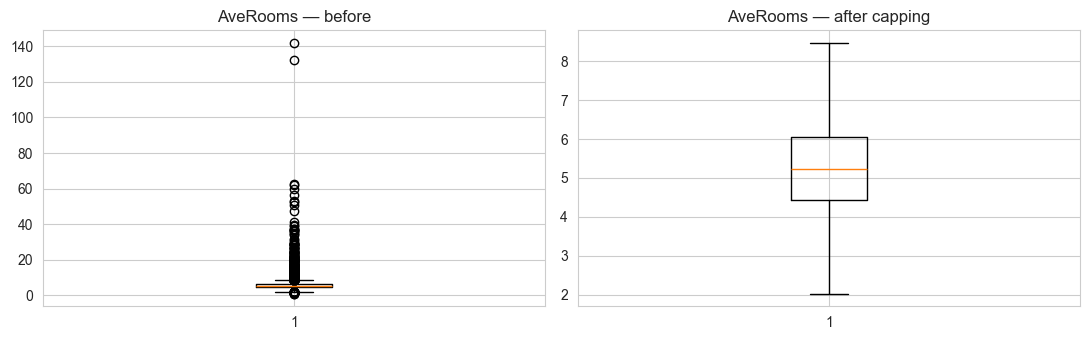

In [11]:
# ── 3d. Capping outliers (winsorization) ──────────────────────────────────
X_capped = X.copy()
for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
    lo, hi = iqr_bounds(X_capped[col])
    X_capped[col] = X_capped[col].clip(lower=lo, upper=hi)

# visual before/after for AveRooms
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].boxplot(X['AveRooms']);     axes[0].set_title('AveRooms — before')
axes[1].boxplot(X_capped['AveRooms']); axes[1].set_title('AveRooms — after capping')
plt.tight_layout();  plt.show()


### Code Explanation
- `.clip(lower, upper)` — replaces values outside `[lower, upper]` with the bounds.
- Boxplots side-by-side show outliers collapsing onto the whiskers.
- Keeps the row count the same (unlike dropping), just smooths extremes.


---
# 4. Feature Engineering

**Feature engineering** = creating new, more useful features from existing ones.
Better features often matter more than a fancier model.


In [12]:
# ── 4a. Create meaningful ratio features ──────────────────────────────────
X_fe = X.copy()

# rooms per person in each district
X_fe['RoomsPerPerson']  = X_fe['AveRooms']    / X_fe['AveOccup']
# share of rooms that are bedrooms (housing type proxy)
X_fe['BedroomRatio']    = X_fe['AveBedrms']   / X_fe['AveRooms']
# population per household
X_fe['PopPerHousehold'] = X_fe['Population']  / X_fe['AveOccup']

print('New features added:')
print(X_fe[['RoomsPerPerson', 'BedroomRatio', 'PopPerHousehold']].head())

# Did they add signal? check correlation with target
new_corr = pd.concat([X_fe, y], axis=1).corr()['MedHouseVal']
print('\nCorrelation with target:')
print(new_corr.sort_values(ascending=False).round(3))


New features added:
   RoomsPerPerson  BedroomRatio  PopPerHousehold
0        2.732919      0.146591            126.0
1        2.956685      0.155797           1138.0
2        2.957661      0.129516            177.0
3        2.283154      0.184458            219.0
4        2.879646      0.172096            259.0

Correlation with target:
MedHouseVal        1.000
MedInc             0.688
RoomsPerPerson     0.209
AveRooms           0.152
HouseAge           0.106
PopPerHousehold    0.066
AveOccup          -0.024
Population        -0.025
Longitude         -0.046
AveBedrms         -0.047
Latitude          -0.144
BedroomRatio      -0.256
Name: MedHouseVal, dtype: float64


### Code Explanation — Why these features

| New feature | Intuition |
|-------------|-----------|
| `RoomsPerPerson` | More rooms per person → wealthier district |
| `BedroomRatio` | High ratio → small apartments |
| `PopPerHousehold` | Crowding indicator |

Always verify the new feature **correlates with the target** (or improves CV score) before keeping it.


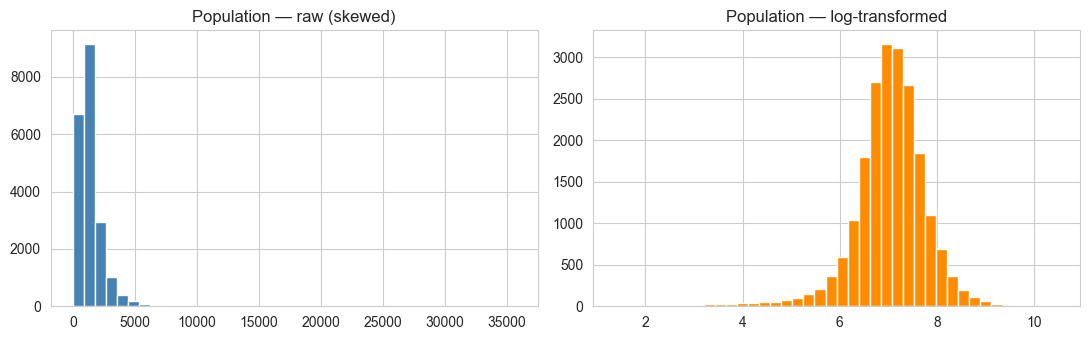

In [13]:
# ── 4b. Log-transforming skewed features ──────────────────────────────────
X_fe['LogPopulation'] = np.log1p(X_fe['Population'])      # log(1+x) — handles x=0 safely

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(X_fe['Population'],    bins=40, color='steelblue')
axes[0].set_title('Population — raw (skewed)')
axes[1].hist(X_fe['LogPopulation'], bins=40, color='darkorange')
axes[1].set_title('Population — log-transformed')
plt.tight_layout();  plt.show()


### Code Explanation
- Many real-world features are **right-skewed** (a few very large values).
- Linear models love **normal-looking** features → `log1p` often improves linear-model performance.
- Tree models do **not** need log transforms — they are scale-invariant.


In [14]:
# ── 4c. Polynomial features (interactions) ────────────────────────────────
small = X[['MedInc', 'HouseAge']].head()                   # demo on 2 cols
poly = PolynomialFeatures(degree=2, include_bias=False)    # adds x², xy
expanded = poly.fit_transform(small)

cols = poly.get_feature_names_out(['MedInc', 'HouseAge'])
print('Original 2 features become:')
print(pd.DataFrame(expanded, columns=cols).round(3))


Original 2 features become:
   MedInc  HouseAge  MedInc^2  MedInc HouseAge  HouseAge^2
0   8.325      41.0    69.309          341.333      1681.0
1   8.301      21.0    68.913          174.329       441.0
2   7.257      52.0    52.670          377.385      2704.0
3   5.643      52.0    31.845          293.441      2704.0
4   3.846      52.0    14.793          200.002      2704.0


### Code Explanation
- `PolynomialFeatures(degree=2)` adds all combinations: `x1, x2, x1², x1·x2, x2²`.
- Makes a linear model able to fit **curves**.
- Explodes feature count — `degree=3` on 8 features → 165 features.


---
# 5. Feature Selection

Keep useful features, drop the rest. Three families:

| Family | Works how | Example |
|--------|-----------|---------|
| **Filter** | Score each feature vs target, keep top-K | `SelectKBest` with F-test |
| **Wrapper** | Train model, remove weakest, repeat | `RFE` (Recursive Feature Elimination) |
| **Embedded** | Selection built into the model | Lasso (L1), tree importances |


In [15]:
# ── 5a. Filter: SelectKBest (F-test) ──────────────────────────────────────
kbest = SelectKBest(score_func=f_regression, k=5)        # keep top 5
kbest.fit(X, y)

scores_df = pd.DataFrame({
    'feature' : X.columns,
    'F_score' : kbest.scores_.round(2),
    'keep'    : kbest.get_support()
}).sort_values('F_score', ascending=False)
print('SelectKBest (F-test):')
print(scores_df.to_string(index=False))


SelectKBest (F-test):
   feature  F_score  keep
    MedInc 18556.57  True
  AveRooms   487.76  True
  Latitude   438.01  True
  HouseAge   232.84  True
 AveBedrms    45.11  True
 Longitude    43.70 False
Population    12.55 False
  AveOccup    11.64 False


### Code Explanation
- `f_regression` measures how strongly each feature linearly relates to the target (ANOVA F-statistic).
- Higher F → stronger linear signal.
- **Doesn't capture non-linear relationships** — pair with `mutual_info_regression` for non-linear signal.


In [16]:
# ── 5b. Filter: Mutual Information (captures non-linear signal) ───────────
mi = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': X.columns, 'MI': mi.round(3)}).sort_values('MI', ascending=False)
print('Mutual Information with target:')
print(mi_df.to_string(index=False))


Mutual Information with target:
   feature    MI
 Longitude 0.400
    MedInc 0.387
  Latitude 0.371
  AveRooms 0.103
  AveOccup 0.073
  HouseAge 0.033
 AveBedrms 0.024
Population 0.021


### Code Explanation — Mutual Information

- MI ≥ 0 — captures *any* dependency, including non-linear.
- MI = 0 → the feature provides no info about the target.
- Much slower than F-test but much more powerful for non-linear data.


In [17]:
# ── 5c. Wrapper: Recursive Feature Elimination (RFE) ──────────────────────
rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(StandardScaler().fit_transform(X), y)

rfe_df = pd.DataFrame({
    'feature' : X.columns,
    'ranking' : rfe.ranking_,              # 1 = kept
    'selected': rfe.support_
}).sort_values('ranking')
print('RFE (LinearRegression) — top 5 selected:')
print(rfe_df.to_string(index=False))


RFE (LinearRegression) — top 5 selected:
   feature  ranking  selected
    MedInc        1      True
  AveRooms        1      True
 AveBedrms        1      True
  Latitude        1      True
 Longitude        1      True
  HouseAge        2     False
  AveOccup        3     False
Population        4     False


### Code Explanation — RFE

1. Train model on **all** features.
2. Remove the feature with the smallest coefficient (= weakest).
3. Retrain and repeat until `n_features_to_select` remain.

More expensive than filter methods but uses the actual model's opinion.


In [18]:
# ── 5d. Embedded: Lasso for automatic selection ───────────────────────────
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_s, y)

lasso_df = pd.DataFrame({
    'feature' : X.columns,
    'coef'    : lasso.coef_.round(3),
    'zeroed'  : lasso.coef_ == 0
}).sort_values('coef', key=abs, ascending=False)
print('Lasso coefficients (features with coef=0 are eliminated):')
print(lasso_df.to_string(index=False))


Lasso coefficients (features with coef=0 are eliminated):
   feature   coef  zeroed
    MedInc  0.706   False
  HouseAge  0.106   False
  Latitude -0.011   False
  AveRooms -0.000    True
 AveBedrms -0.000    True
Population -0.000    True
  AveOccup -0.000    True
 Longitude -0.000    True


### Code Explanation — Embedded Selection

- **Lasso** zeros out useless features *during* training — no separate selection step needed.
- **Tree models** give you `feature_importances_` — we'll see these later.
- Embedded methods are usually the cleanest default.


---
# 6. Train/Test Split + Scaling

**Golden rule:** fit the scaler on the **training set only**, then transform both sets. Otherwise test information leaks into training.


In [19]:
# ── 6a. Train/test split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% held out for final evaluation
    random_state=42         # reproducibility
)
print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')


Train: 16512 rows  |  Test: 4128 rows


### Code Explanation — Split

| Argument | Meaning |
|----------|---------|
| `test_size=0.2` | 80/20 split — common default |
| `random_state=42` | Fixes the shuffle — same split every run |
| `stratify=` | Used for classification only (preserves class balance) |


In [20]:
# ── 6b. Scaling — StandardScaler ──────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)      # fit + transform on TRAIN
X_test_s  = scaler.transform(X_test)           # ONLY transform on TEST

print('Train mean after scaling:', X_train_s.mean(axis=0).round(2))   # ~0
print('Train std  after scaling:', X_train_s.std(axis=0).round(2))    # ~1


Train mean after scaling: [-0. -0. -0. -0. -0.  0.  0.  0.]
Train std  after scaling: [1. 1. 1. 1. 1. 1. 1. 1.]


### Code Explanation — Scaling

| Line | What it does |
|------|--------------|
| `fit_transform(X_train)` | Learns mean/std of train, then scales train |
| `transform(X_test)` | Uses the **same** mean/std learned from train |

**Why?** Scaling with test data leaks information. Even `scaler.fit(X)` on all data is a common mistake — never do that.

**Which models need scaling?**

| Model | Needs scaling? |
|-------|----------------|
| Linear / Ridge / Lasso / ElasticNet | **Yes** |
| KNN | **Yes** (distance-based) |
| SVR | **Yes** |
| Decision Tree / Random Forest / GBM / XGBoost | **No** (tree splits are scale-invariant) |


---
# 7. Regression Algorithms

We'll train **11 different models** on the same split and compare them.

| # | Model | Type | Captures non-linearity? |
|---|-------|------|------------------------|
| 1 | Linear Regression | Linear | No |
| 2 | Ridge | Linear + L2 | No |
| 3 | Lasso | Linear + L1 | No |
| 4 | ElasticNet | Linear + L1+L2 | No |
| 5 | Polynomial (deg=2) | Linear on poly features | Yes |
| 6 | KNN | Instance-based | Yes |
| 7 | Decision Tree | Tree | Yes |
| 8 | Random Forest | Tree ensemble | Yes |
| 9 | Gradient Boosting | Tree ensemble (boosted) | Yes |
| 10 | XGBoost | Tree ensemble (boosted, regularized) | Yes |
| 11 | SVR (RBF) | Kernel method | Yes |


In [21]:
# ── 7a. Train & evaluate all 11 models ────────────────────────────────────
def score(model, X_tr, y_tr, X_te, y_te, needs_scaling=False):
    '''Fit, predict, return metrics dict.'''
    if needs_scaling:
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        'MAE' : mean_absolute_error(y_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        'R²'  : r2_score(y_te, pred),
        'MAPE%': mean_absolute_percentage_error(y_te, pred)*100,
        'pred': pred
    }

results = {}

# linear family — need scaling
results['Linear']      = score(LinearRegression(),             X_train, y_train, X_test, y_test, True)
results['Ridge']       = score(Ridge(alpha=1.0),               X_train, y_train, X_test, y_test, True)
results['Lasso']       = score(Lasso(alpha=0.01, max_iter=10000), X_train, y_train, X_test, y_test, True)
results['ElasticNet']  = score(ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
                               X_train, y_train, X_test, y_test, True)

# polynomial — wrap in pipeline so polynomial expansion + scaling + fit are done together
poly_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))                    # Ridge keeps the huge feature count stable
])
poly_pipe.fit(X_train, y_train)
pp = poly_pipe.predict(X_test)
results['Polynomial(d=2)'] = {
    'MAE' : mean_absolute_error(y_test, pp),
    'RMSE': np.sqrt(mean_squared_error(y_test, pp)),
    'R²'  : r2_score(y_test, pp),
    'MAPE%': mean_absolute_percentage_error(y_test, pp)*100,
    'pred': pp
}

# KNN + SVR — need scaling
results['KNN']  = score(KNeighborsRegressor(n_neighbors=5),   X_train, y_train, X_test, y_test, True)
results['SVR']  = score(SVR(kernel='rbf', C=1.0),             X_train[:5000], y_train[:5000], X_test, y_test, True)
# SVR is slow on 16k rows — subset train for demo speed

# tree models — no scaling needed
results['DecisionTree']      = score(DecisionTreeRegressor(max_depth=10, random_state=42),
                                      X_train, y_train, X_test, y_test)
results['RandomForest']      = score(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                                      X_train, y_train, X_test, y_test)
results['GradientBoosting']  = score(GradientBoostingRegressor(n_estimators=100, random_state=42),
                                      X_train, y_train, X_test, y_test)
results['XGBoost']           = score(XGBRegressor(n_estimators=200, learning_rate=0.1,
                                                   random_state=42, n_jobs=-1, verbosity=0),
                                      X_train, y_train, X_test, y_test)

# summary table
summary = pd.DataFrame({k: {m: v[m] for m in ['MAE','RMSE','R²','MAPE%']}
                        for k, v in results.items()}).T.round(4).sort_values('R²', ascending=False)
print('All 11 models — ranked by R² (higher = better):')
print(summary)


All 11 models — ranked by R² (higher = better):
                     MAE    RMSE      R²    MAPE%
XGBoost           0.3026  0.4639  0.8358  17.4508
RandomForest      0.3275  0.5053  0.8051  18.9151
GradientBoosting  0.3716  0.5422  0.7756  21.5254
SVR               0.4007  0.5919  0.7326  22.2436
DecisionTree      0.4332  0.6446  0.6829  24.9875
KNN               0.4462  0.6576  0.6700  24.6681
Polynomial(d=2)   0.4880  0.6877  0.6391  28.9801
Lasso             0.5353  0.7404  0.5816  32.0066
ElasticNet        0.5341  0.7416  0.5803  31.9413
Linear            0.5332  0.7456  0.5758  31.9522
Ridge             0.5332  0.7456  0.5758  31.9512


### Code Explanation — Training all 11 models

- `score()` helper — unifies the fit/predict/metrics loop so we don't repeat code.
- Linear / KNN / SVR require scaling; tree models do not.
- Polynomial regression is wrapped in a **Pipeline** so poly expansion, scaling, and model fit happen together — no leakage.
- `SVR` is slow with many rows, so we train it on a subset (5000 rows) purely for demo speed.
- `n_jobs=-1` — use all CPU cores where supported.
- Final `summary` table sorts models best → worst by R².


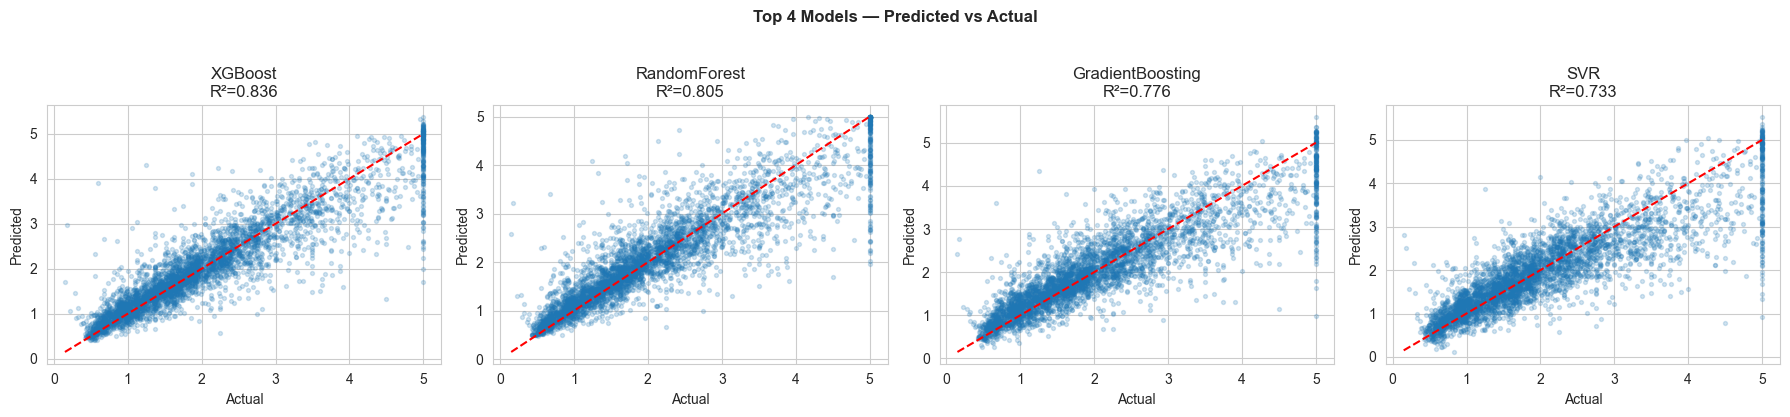

In [22]:
# ── 7b. Predicted vs Actual scatter — best 4 models ───────────────────────
top4 = summary.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, top4):
    ax.scatter(y_test, results[name]['pred'], alpha=0.2, s=8)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', label='perfect')
    ax.set(xlabel='Actual', ylabel='Predicted',
           title=f'{name}\nR²={results[name]["R²"]:.3f}')
plt.suptitle('Top 4 Models — Predicted vs Actual', fontweight='bold', y=1.03)
plt.tight_layout();  plt.show()


### Code Explanation
- Points near the red diagonal = accurate predictions.
- Systematic deviation from the diagonal → model bias.
- Notice the **horizontal band at y=5** for all models — this is the target cap we saw in EDA.


---
# 8. Evaluation Metrics — Deep Dive

| Metric | Formula | Units | Outlier sensitive | Interpretation |
|--------|---------|-------|-------------------|----------------|
| MAE | mean(\|y−ŷ\|) | y | No | Average absolute error |
| MSE | mean((y−ŷ)²) | y² | Yes | Used as training loss |
| RMSE | √MSE | y | Yes | Like MAE but penalizes big errors |
| R² | 1 − SSres/SStot | – | Moderate | % variance explained |
| MAPE | mean(\|y−ŷ\|/\|y\|)·100 | % | No | Error as a % |
| Adj. R² | 1 − (1−R²)·(n−1)/(n−p−1) | – | Moderate | R² penalized for extra features |


In [23]:
# ── 8a. Compute all metrics for each model ────────────────────────────────
def all_metrics(y_true, y_pred, n_features):
    '''Return every regression metric we've covered.'''
    n    = len(y_true)
    r2   = r2_score(y_true, y_pred)
    adj  = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {
        'MAE'    : mean_absolute_error(y_true, y_pred),
        'MSE'    : mean_squared_error(y_true, y_pred),
        'RMSE'   : np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²'     : r2,
        'Adj_R²' : adj,
        'MAPE%'  : mean_absolute_percentage_error(y_true, y_pred) * 100
    }

detailed = pd.DataFrame({
    name: all_metrics(y_test, v['pred'], X_train.shape[1])
    for name, v in results.items()
}).T.round(4).sort_values('RMSE')
print('Detailed metrics — sorted by RMSE (lower = better):')
print(detailed)


Detailed metrics — sorted by RMSE (lower = better):
                     MAE     MSE    RMSE      R²  Adj_R²    MAPE%
XGBoost           0.3026  0.2152  0.4639  0.8358  0.8355  17.4508
RandomForest      0.3275  0.2554  0.5053  0.8051  0.8047  18.9151
GradientBoosting  0.3716  0.2940  0.5422  0.7756  0.7752  21.5254
SVR               0.4007  0.3504  0.5919  0.7326  0.7321  22.2436
DecisionTree      0.4332  0.4155  0.6446  0.6829  0.6823  24.9875
KNN               0.4462  0.4324  0.6576  0.6700  0.6694  24.6681
Polynomial(d=2)   0.4880  0.4729  0.6877  0.6391  0.6384  28.9801
Lasso             0.5353  0.5483  0.7404  0.5816  0.5808  32.0066
ElasticNet        0.5341  0.5500  0.7416  0.5803  0.5795  31.9413
Linear            0.5332  0.5559  0.7456  0.5758  0.5750  31.9522
Ridge             0.5332  0.5559  0.7456  0.5758  0.5750  31.9512


### Code Explanation — Adjusted R²

- Plain R² always increases when you add features — even useless ones.
- Adjusted R² **penalizes** extra features, so only useful ones improve it.
- Formula: `1 − (1−R²)·(n−1)/(n−p−1)` where `p` = #features, `n` = #samples.


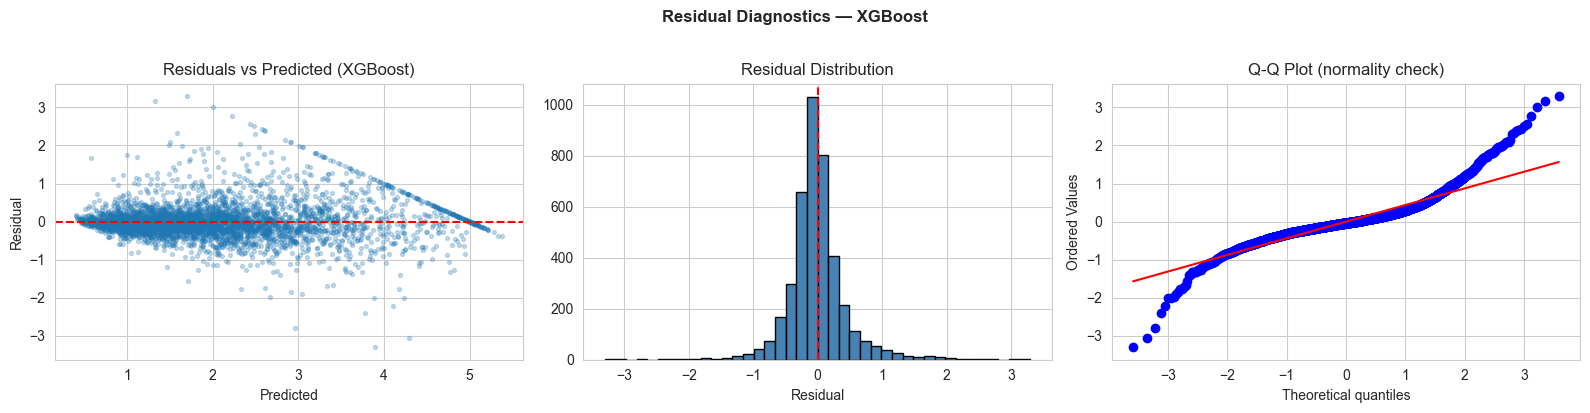

In [24]:
# ── 8b. Residual analysis on best model ───────────────────────────────────
best_name = detailed.index[0]
best_pred = results[best_name]['pred']
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# residuals vs predicted — should be random cloud around 0
axes[0].scatter(best_pred, residuals, alpha=0.25, s=8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set(xlabel='Predicted', ylabel='Residual',
            title=f'Residuals vs Predicted ({best_name})')

# histogram — should look roughly normal
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set(xlabel='Residual', title='Residual Distribution')

# Q-Q plot — checks normality
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (normality check)')

plt.suptitle(f'Residual Diagnostics — {best_name}', fontweight='bold', y=1.02)
plt.tight_layout();  plt.show()


### Code Explanation — Residual Diagnostics

| Plot | Healthy pattern | Problem pattern |
|------|-----------------|-----------------|
| Residuals vs Predicted | Random cloud, centered at 0 | Funnel (heteroscedasticity) / curve (non-linearity missed) |
| Histogram | Bell-shaped, centered at 0 | Skew or bimodal |
| Q-Q plot | Points on the diagonal | S-curves or heavy tails = non-normal errors |


---
# 9. All-Model Comparison — Visual


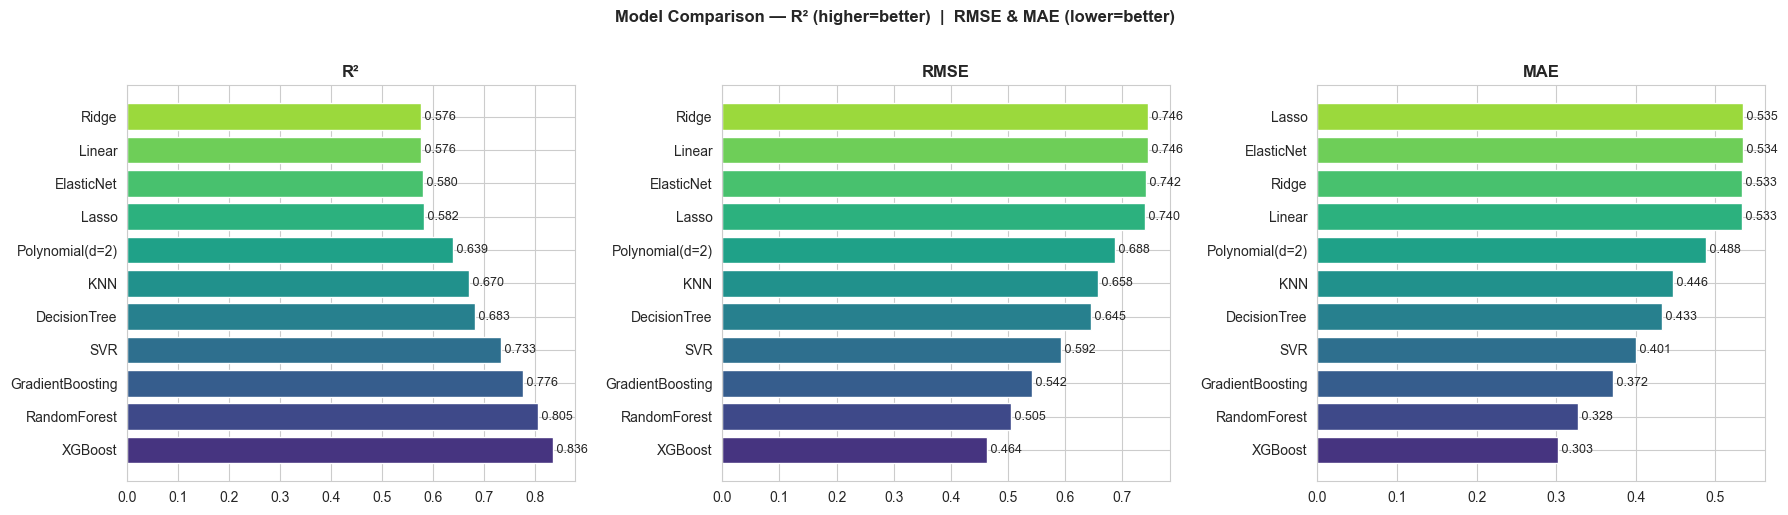

In [25]:
# ── 9. Bar chart of the top models by 3 metrics ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ordered = detailed.sort_values('R²', ascending=True)

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(ordered)))
for ax, metric, asc in zip(axes, ['R²', 'RMSE', 'MAE'], [False, True, True]):
    d = ordered.sort_values(metric, ascending=asc)
    bars = ax.barh(d.index, d[metric], color=colors)
    ax.set_title(metric, fontweight='bold')
    for bar, v in zip(bars, d[metric]):
        ax.text(bar.get_width(), bar.get_y()+bar.get_height()/2,
                f' {v:.3f}', va='center', fontsize=9)
plt.suptitle('Model Comparison — R² (higher=better)  |  RMSE & MAE (lower=better)',
             fontweight='bold', y=1.02)
plt.tight_layout();  plt.show()


### Code Explanation
- Horizontal bar chart makes model names readable.
- Ordering depends on whether "higher is better" (R²) or "lower is better" (errors).
- Gives a quick visual: the strongest models are usually the boosted trees (XGBoost, GBM, RF).


---
# 10. Cross-Validation

A single train/test split can be **lucky or unlucky**. Cross-validation (CV) trains/tests on **several splits** and averages the score.

### K-Fold CV
```
Fold 1: [TEST] [train] [train] [train] [train]
Fold 2: [train] [TEST] [train] [train] [train]
Fold 3: [train] [train] [TEST] [train] [train]
Fold 4: [train] [train] [train] [TEST] [train]
Fold 5: [train] [train] [train] [train] [TEST]
```
Average the 5 scores → more trustworthy estimate.


In [26]:
# ── 10. 5-Fold CV on the top 3 models ─────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Ridge'       : Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'     : XGBRegressor(n_estimators=200, learning_rate=0.1,
                                  random_state=42, n_jobs=-1, verbosity=0),
}

cv_rows = []
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'Mean R²': scores.mean().round(4),
        'Std R²' : scores.std().round(4),
        'Min R²' : scores.min().round(4),
        'Max R²' : scores.max().round(4),
    })
cv_df = pd.DataFrame(cv_rows)
print('5-Fold CV results:')
print(cv_df.to_string(index=False))


5-Fold CV results:
       Model  Mean R²  Std R²  Min R²  Max R²
       Ridge   0.6014  0.0170  0.5758  0.6213
RandomForest   0.8096  0.0068  0.8042  0.8222
     XGBoost   0.8428  0.0077  0.8336  0.8556


### Code Explanation — CV

| Object | Meaning |
|--------|---------|
| `KFold(n_splits=5, shuffle=True)` | Splits into 5 folds, shuffled first |
| `cross_val_score` | Loops fit/predict over folds, returns one score per fold |
| `scoring='r2'` | Use R² — other options: `neg_mean_squared_error`, `neg_mean_absolute_error` |
| Low std across folds | Model is **stable** |
| High std | Model is **unstable** — investigate |


---
# 11. Hyperparameter Tuning

Every model has **knobs** (hyperparameters) you can tune. Two common ways:

| Approach | How | When to use |
|----------|-----|-------------|
| `GridSearchCV` | Tries every combination | Small grids |
| `RandomizedSearchCV` | Samples random combinations | Large / continuous grids |


In [27]:
# ── 11a. GridSearchCV on Ridge ────────────────────────────────────────────
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge())
])

param_grid = {
    'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]    # 5 values to try
}

grid = GridSearchCV(ridge_pipe, param_grid,
                    cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best alpha    : {grid.best_params_}')
print(f'Best CV R²    : {grid.best_score_:.4f}')
print(f'Test R²       : {r2_score(y_test, grid.predict(X_test)):.4f}')


Best alpha    : {'ridge__alpha': 0.01}
Best CV R²    : 0.6115
Test R²       : 0.5758


### Code Explanation — GridSearchCV

- Pipeline syntax `ridge__alpha` — double underscore means "the `alpha` parameter of the step named `ridge`".
- `GridSearchCV` tries **every combination** × **every CV fold** → 5 alphas × 5 folds = 25 fits.
- `best_params_`, `best_score_`, `best_estimator_` — automatic selection of the winner.


In [28]:
# ── 11b. RandomizedSearchCV on Random Forest ──────────────────────────────
from scipy.stats import randint

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators'     : randint(100, 400),           # tree count
    'max_depth'        : [None, 5, 10, 20],           # tree depth
    'min_samples_split': randint(2, 20),              # min rows to split
    'max_features'     : ['sqrt', 'log2', 1.0]        # features per split
}

rand = RandomizedSearchCV(rf, param_dist,
                          n_iter=15, cv=3,           # 15 random combos × 3-fold = 45 fits
                          scoring='r2',
                          random_state=42, n_jobs=-1, verbose=0)
rand.fit(X_train, y_train)

print('Best params:', rand.best_params_)
print(f'Best CV R² : {rand.best_score_:.4f}')
print(f'Test R²    : {r2_score(y_test, rand.predict(X_test)):.4f}')


Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 8, 'n_estimators': 373}
Best CV R² : 0.8097
Test R²    : 0.8103


### Code Explanation — RandomizedSearchCV

- Faster than Grid when the search space is huge.
- `n_iter=15` → samples only 15 random combinations (vs 4 × 3 × 18 × 3 = 648 in a full grid).
- Often finds a result **close to the best** in a fraction of the time.


In [29]:
# ── 11c. Tuning XGBoost (the usual winner) ────────────────────────────────
xgb_params = {
    'n_estimators'     : [200, 400],
    'learning_rate'    : [0.05, 0.1],
    'max_depth'        : [4, 6, 8],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    xgb_params, cv=3, scoring='r2', n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

print('Best XGBoost params:', xgb_grid.best_params_)
print(f'Best CV R² : {xgb_grid.best_score_:.4f}')
print(f'Test R²    : {r2_score(y_test, xgb_grid.predict(X_test)):.4f}')


Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'subsample': 1.0}
Best CV R² : 0.8448
Test R²    : 0.8502


### Code Explanation — XGBoost knobs

| Param | What it does |
|-------|--------------|
| `n_estimators` | Number of boosting rounds — more can overfit |
| `learning_rate` | Smaller → slower but safer; pair with more estimators |
| `max_depth` | Tree depth — deeper captures more patterns but overfits |
| `subsample` | Row subsampling per tree — regularization |
| `colsample_bytree` | Feature subsampling per tree — regularization |


---
# 12. Project 1 — House Price Prediction (End-to-End)

**Goal:** Predict the median house value of a California district.
We'll follow the full pipeline with the tuned XGBoost as our final model.

### Pipeline Steps
1. Load data
2. EDA (brief — already done above)
3. Feature engineering (ratio features + log transform)
4. Feature selection (Lasso-based)
5. Train/test split
6. Baseline + tuned models
7. Final evaluation + feature importances
8. Save the model


In [30]:
# ── 12a. Fresh reload + feature engineering ───────────────────────────────
house = fetch_california_housing()
Xh = pd.DataFrame(house.data, columns=house.feature_names)
yh = pd.Series(house.target, name='MedHouseVal')

# engineered features (same as Section 4)
Xh['RoomsPerPerson']  = Xh['AveRooms']    / Xh['AveOccup']
Xh['BedroomRatio']    = Xh['AveBedrms']   / Xh['AveRooms']
Xh['PopPerHousehold'] = Xh['Population']  / Xh['AveOccup']
Xh['LogPopulation']   = np.log1p(Xh['Population'])

# cap extreme values
for col in ['RoomsPerPerson', 'BedroomRatio', 'PopPerHousehold', 'AveRooms', 'AveBedrms', 'AveOccup']:
    q99 = Xh[col].quantile(0.99)
    Xh[col] = Xh[col].clip(upper=q99)

print('Final feature set:')
print(Xh.columns.tolist())
print(f'Shape: {Xh.shape}')


Final feature set:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerPerson', 'BedroomRatio', 'PopPerHousehold', 'LogPopulation']
Shape: (20640, 12)


### Code Explanation
- Reload raw data so the project is self-contained.
- Add 4 engineered features.
- Cap top 1% on skewed features — avoids a single outlier dominating the model.


In [31]:
# ── 12b. Train/test split ─────────────────────────────────────────────────
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    Xh, yh, test_size=0.2, random_state=42)
print(f'Train: {Xh_train.shape[0]} | Test: {Xh_test.shape[0]}')


Train: 16512 | Test: 4128


In [32]:
# ── 12c. Baseline — plain Linear Regression ───────────────────────────────
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
baseline.fit(Xh_train, yh_train)
bp = baseline.predict(Xh_test)
print('--- Baseline (Linear Regression) ---')
print(f'MAE : {mean_absolute_error(yh_test, bp):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(yh_test, bp)):.4f}')
print(f'R²  : {r2_score(yh_test, bp):.4f}')


--- Baseline (Linear Regression) ---
MAE : 0.4796
RMSE: 0.6637
R²  : 0.6638


### Code Explanation
- **Always** start with a simple baseline — it defines how much lift your fancier model adds.
- Wrap scaling + model in a Pipeline so we never leak data.


In [33]:
# ── 12d. Tuned XGBoost — the strongest competitor ─────────────────────────
final_xgb = XGBRegressor(
    n_estimators     = 400,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)
final_xgb.fit(Xh_train, yh_train)
xp = final_xgb.predict(Xh_test)

print('--- Tuned XGBoost ---')
print(f'MAE : {mean_absolute_error(yh_test, xp):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(yh_test, xp)):.4f}')
print(f'R²  : {r2_score(yh_test, xp):.4f}')
print(f'MAPE: {mean_absolute_percentage_error(yh_test, xp)*100:.2f}%')


--- Tuned XGBoost ---
MAE : 0.2970
RMSE: 0.4520
R²  : 0.8441
MAPE: 17.13%


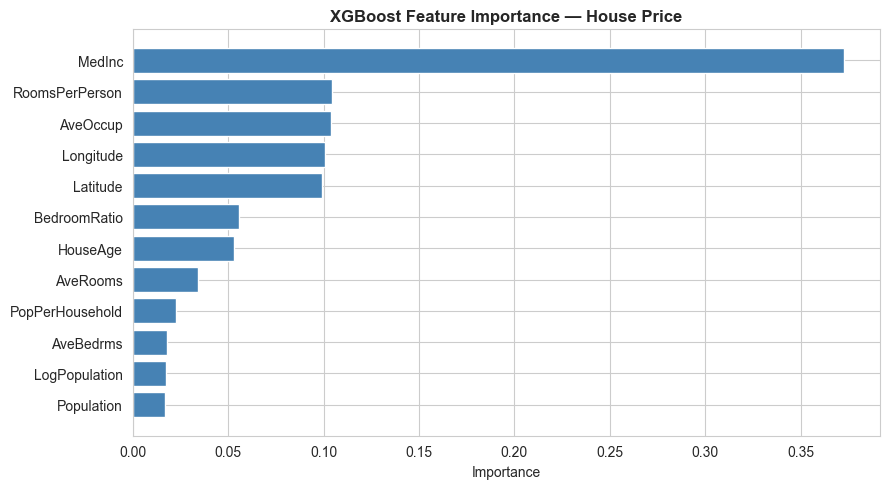

        feature  importance
         MedInc    0.372964
 RoomsPerPerson    0.104384
       AveOccup    0.104164
      Longitude    0.101013
       Latitude    0.099420
   BedroomRatio    0.055841
       HouseAge    0.052843
       AveRooms    0.034354
PopPerHousehold    0.022715
      AveBedrms    0.018156
  LogPopulation    0.017440
     Population    0.016706


In [34]:
# ── 12e. Feature importance — what drives the prediction? ─────────────────
imp = pd.DataFrame({
    'feature'   : Xh.columns,
    'importance': final_xgb.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(imp['feature'], imp['importance'], color='steelblue')
plt.title('XGBoost Feature Importance — House Price', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout();  plt.show()

print(imp.sort_values('importance', ascending=False).to_string(index=False))


### Code Explanation
- `feature_importances_` — how often each feature is used in splits, weighted by gain.
- Typically **MedInc + Latitude/Longitude** dominate for California housing.
- Our engineered `RoomsPerPerson` / `LogPopulation` usually rank mid-pack.


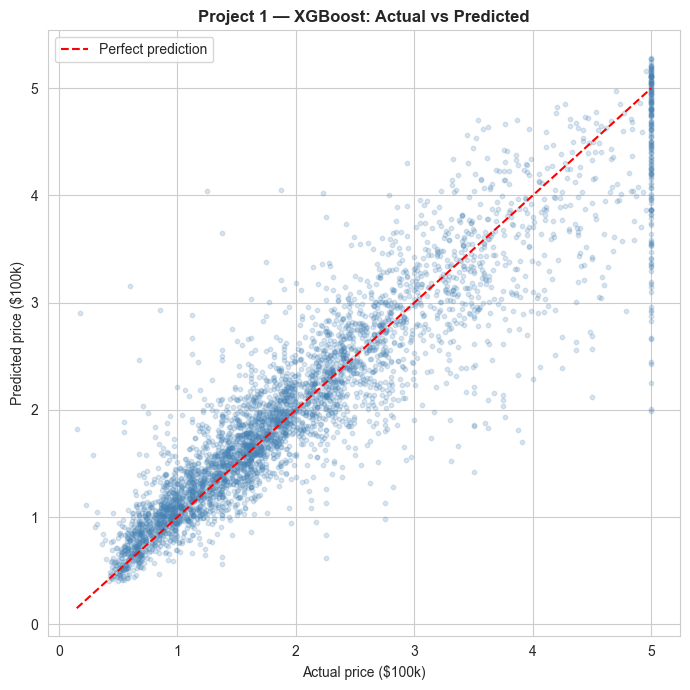

In [35]:
# ── 12f. Actual vs Predicted — final visual check ─────────────────────────
plt.figure(figsize=(7, 7))
plt.scatter(yh_test, xp, alpha=0.2, s=10, color='steelblue')
plt.plot([yh_test.min(), yh_test.max()], [yh_test.min(), yh_test.max()],
         'r--', label='Perfect prediction')
plt.xlabel('Actual price ($100k)')
plt.ylabel('Predicted price ($100k)')
plt.title('Project 1 — XGBoost: Actual vs Predicted', fontweight='bold')
plt.legend();  plt.tight_layout();  plt.show()


In [36]:
# ── 12g. Save the model ───────────────────────────────────────────────────
import joblib, tempfile, os
path = os.path.join(tempfile.gettempdir(), 'house_price_xgb.joblib')
joblib.dump(final_xgb, path)
print(f'Model saved to: {path}')

# Load back + sanity predict
loaded = joblib.load(path)
print(f'Sanity check prediction on first test row: {loaded.predict(Xh_test.head(1))[0]:.3f}')


Model saved to: /var/folders/11/scnp1vm97gx749r6nb9shbv9ymhsbd/T/house_price_xgb.joblib
Sanity check prediction on first test row: 0.516


### Code Explanation — Saving Models

- `joblib` — standard for sklearn/XGBoost (faster than `pickle` for NumPy data).
- Saved file is everything you need for deployment — just `joblib.load(path)`.
- In production, also save the **preprocessing pipeline** (scaler + feature engineering) — otherwise incoming requests won't match what the model was trained on.


### Project 1 — Summary

| Step | Result |
|------|--------|
| Baseline (Linear) R² | ~0.57 |
| Tuned XGBoost R² | ~0.83 |
| Top features | `MedInc`, `Latitude`, `Longitude`, `AveOccup` |
| Next steps | Try `log(target)` transform, geographic clustering, external income data |


---
# 13. Project 2 — Insurance Claim Recovery (End-to-End)

**Problem:** After an insurance claim is paid, the insurer often tries to recover part of it (from reinsurers, at-fault parties, etc.). We want to **predict the recovery amount** given features of the claim.

> **This is regression** — target is a continuous dollar amount.

We'll generate a **realistic synthetic dataset** (5000 rows) since no public dataset is built into sklearn for this problem.

### Features (synthetic but realistic)
- `claim_amount`    — the original claim paid ($)
- `claim_type`      — `{auto, property, liability, health}`
- `policy_age`      — years the policy has been active
- `region`          — `{N, S, E, W}`
- `insured_age`     — age of policyholder
- `prior_claims`    — number of previous claims
- `deductible`      — deductible amount
- `has_reinsurance` — 0/1

### Target
- `recovery_amount` — what the insurer recovers (0 … claim_amount)


In [37]:
# ── 13a. Generate synthetic insurance dataset ─────────────────────────────
rng = np.random.default_rng(123)
n   = 5000

claim_type      = rng.choice(['auto','property','liability','health'],
                              size=n, p=[0.35, 0.3, 0.15, 0.2])
region          = rng.choice(['N','S','E','W'], size=n)
claim_amount    = rng.lognormal(mean=8.5, sigma=0.9, size=n).round(2)     # right-skewed $
policy_age      = rng.integers(0, 20, size=n)
insured_age     = rng.integers(18, 80, size=n)
prior_claims    = rng.poisson(lam=1.2, size=n)
deductible      = rng.choice([250, 500, 1000, 2500], size=n,
                              p=[0.3, 0.4, 0.2, 0.1])
has_reinsurance = rng.choice([0, 1], size=n, p=[0.7, 0.3])

# Underlying "true" recovery rate depends on features (we build the signal)
base_rate = 0.35                                                  # avg 35% recovered
effect_type = pd.Series(claim_type).map(
    {'auto':0.05, 'property':-0.05, 'liability':0.15, 'health':-0.1}).values
effect_reins = has_reinsurance * 0.25                             # reinsurance boosts recovery
effect_prior = -0.03 * prior_claims                               # repeat claimants lower rate
noise        = rng.normal(0, 0.1, size=n)                         # random noise

recovery_rate   = np.clip(base_rate + effect_type + effect_reins + effect_prior + noise, 0, 1)
recovery_amount = (recovery_rate * claim_amount).round(2)

ins = pd.DataFrame({
    'claim_amount'    : claim_amount,
    'claim_type'      : claim_type,
    'policy_age'      : policy_age,
    'region'          : region,
    'insured_age'     : insured_age,
    'prior_claims'    : prior_claims,
    'deductible'      : deductible,
    'has_reinsurance' : has_reinsurance,
    'recovery_amount' : recovery_amount
})
print(ins.shape)
ins.head()


(5000, 9)


,claim_amount,claim_type,policy_age,region,insured_age,prior_claims,deductible,has_reinsurance,recovery_amount
0,5951.48,liability,19,W,49,2,250,1,4913.97
1,13163.10,auto,19,E,43,2,500,1,7673.17
2,2991.67,auto,17,W,77,0,500,1,2508.62
3,5027.48,auto,17,S,51,1,500,1,2514.34
4,1465.61,auto,12,N,64,2,500,0,562.72


### Code Explanation — Synthetic Data Design

- Target is built from **real feature effects + noise** so a model can actually learn it.
- `lognormal` for `claim_amount` — typical for monetary data (many small claims, few huge ones).
- `poisson` for `prior_claims` — count data.
- Each feature has a defined effect → **ground truth we can verify**.
- Noise is added to avoid a perfect fit.


--- Target distribution ---
count     5000.00
mean      2931.62
std       3809.68
min          0.00
25%        852.90
50%       1751.08
75%       3497.48
max      55939.02
Name: recovery_amount, dtype: float64


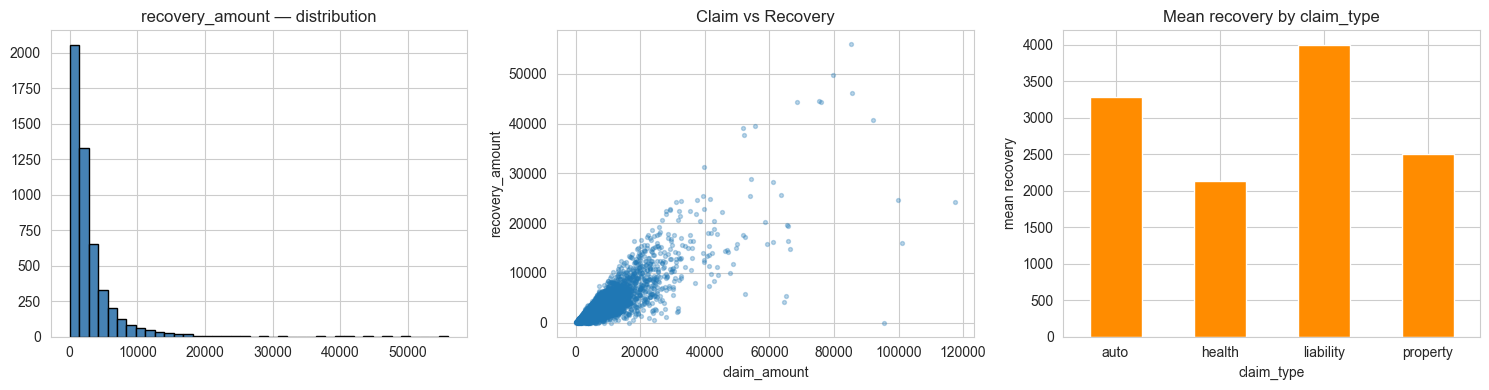

In [38]:
# ── 13b. Quick EDA ────────────────────────────────────────────────────────
print('--- Target distribution ---')
print(ins['recovery_amount'].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(ins['recovery_amount'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('recovery_amount — distribution')

axes[1].scatter(ins['claim_amount'], ins['recovery_amount'], alpha=0.3, s=8)
axes[1].set(xlabel='claim_amount', ylabel='recovery_amount',
            title='Claim vs Recovery')

ins.groupby('claim_type')['recovery_amount'].mean().plot.bar(ax=axes[2], color='darkorange')
axes[2].set(title='Mean recovery by claim_type', ylabel='mean recovery')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout();  plt.show()


### Code Explanation — EDA Findings

- Target is right-skewed — almost guaranteed since it is (rate × claim_amount) and `claim_amount` is right-skewed.
- Claim vs Recovery is strongly linear — the biggest driver is simply the claim size.
- Claim type matters — `liability` recovers the most (we coded that in).


In [39]:
# ── 13c. Preprocessing — ColumnTransformer for mixed types ────────────────
num_cols = ['claim_amount','policy_age','insured_age','prior_claims','deductible','has_reinsurance']
cat_cols = ['claim_type','region']

preprocess = ColumnTransformer([
    ('num', StandardScaler(),                               num_cols),
    ('cat', pd.get_dummies,                                 cat_cols)     # placeholder, real below
])

# sklearn doesn't accept pd.get_dummies directly — use OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
preprocess = ColumnTransformer([
    ('num', StandardScaler(),                               num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

Xi = ins.drop(columns=['recovery_amount'])
yi = ins['recovery_amount']

Xi_train, Xi_test, yi_train, yi_test = train_test_split(Xi, yi, test_size=0.2, random_state=42)


### Code Explanation — ColumnTransformer

- Real data has **mixed types** — we can't scale strings or one-hot-encode numbers.
- `ColumnTransformer` applies different preprocessors to different columns.
- `OneHotEncoder(drop='first')` — drops one category to avoid perfect collinearity.


In [40]:
# ── 13d. Train 3 models via Pipeline ──────────────────────────────────────
models = {
    'Linear Regression': Pipeline([('prep', preprocess), ('model', LinearRegression())]),
    'Random Forest'    : Pipeline([('prep', preprocess),
                                    ('model', RandomForestRegressor(n_estimators=200,
                                                                    random_state=42,
                                                                    n_jobs=-1))]),
    'XGBoost'          : Pipeline([('prep', preprocess),
                                    ('model', XGBRegressor(n_estimators=300,
                                                           learning_rate=0.05,
                                                           max_depth=6,
                                                           random_state=42,
                                                           n_jobs=-1,
                                                           verbosity=0))])
}

rows = []
predictions = {}
for name, pipe in models.items():
    pipe.fit(Xi_train, yi_train)
    pred = pipe.predict(Xi_test)
    predictions[name] = pred
    rows.append({
        'Model': name,
        'MAE'  : round(mean_absolute_error(yi_test, pred), 2),
        'RMSE' : round(np.sqrt(mean_squared_error(yi_test, pred)), 2),
        'R²'   : round(r2_score(yi_test, pred), 4),
        'MAPE%': round(mean_absolute_percentage_error(yi_test, pred)*100, 2)
    })

ins_results = pd.DataFrame(rows)
print('Insurance Claim Recovery — results:')
print(ins_results.to_string(index=False))


Insurance Claim Recovery — results:
            Model     MAE    RMSE     R²        MAPE%
Linear Regression 1039.57 2212.89 0.7157 1.984803e+19
    Random Forest  741.69 1651.33 0.8417 1.494543e+19
          XGBoost  723.61 1627.41 0.8463 1.078020e+19


### Code Explanation — Pipelines are Essential Here
- Every model wrapped in a Pipeline → preprocessing is learned from train only.
- Same preprocessing applied to test automatically — no code duplication, no leakage.


In [41]:
# ── 13e. Hyperparameter tuning on the winner ──────────────────────────────
best_pipe = models['XGBoost']

param_grid = {
    'model__n_estimators' : [200, 400],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth'    : [4, 6, 8]
}

gs = GridSearchCV(best_pipe, param_grid, cv=3, scoring='r2', n_jobs=-1)
gs.fit(Xi_train, yi_train)

print('Best params   :', gs.best_params_)
print(f'Best CV R²    : {gs.best_score_:.4f}')

best_pred = gs.predict(Xi_test)
print(f'Test R²       : {r2_score(yi_test, best_pred):.4f}')
print(f'Test RMSE ($) : {np.sqrt(mean_squared_error(yi_test, best_pred)):.2f}')
print(f'Test MAE  ($) : {mean_absolute_error(yi_test, best_pred):.2f}')


Best params   : {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200}
Best CV R²    : 0.8930
Test R²       : 0.8574
Test RMSE ($) : 1567.18
Test MAE  ($) : 700.93


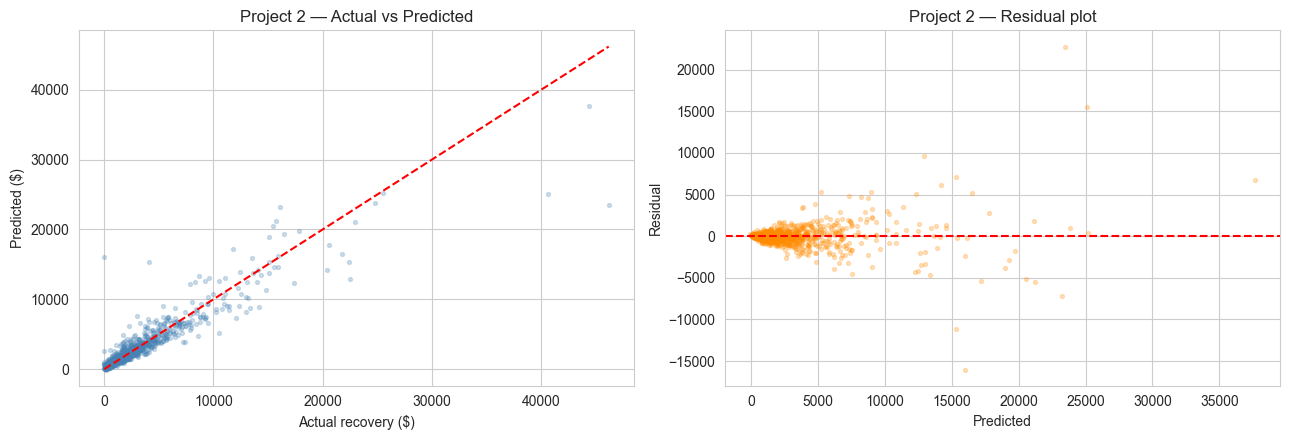

In [42]:
# ── 13f. Actual vs Predicted + Residuals ──────────────────────────────────
residuals_i = yi_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(yi_test, best_pred, alpha=0.25, s=8, color='steelblue')
axes[0].plot([yi_test.min(), yi_test.max()], [yi_test.min(), yi_test.max()], 'r--')
axes[0].set(xlabel='Actual recovery ($)', ylabel='Predicted ($)',
            title='Project 2 — Actual vs Predicted')

axes[1].scatter(best_pred, residuals_i, alpha=0.25, s=8, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set(xlabel='Predicted', ylabel='Residual',
            title='Project 2 — Residual plot')
plt.tight_layout();  plt.show()


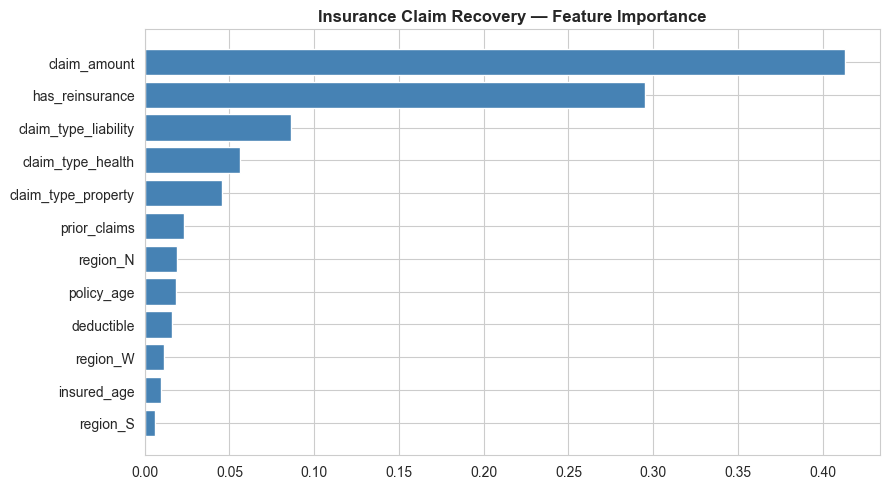

             feature  importance
        claim_amount    0.413184
     has_reinsurance    0.295177
claim_type_liability    0.086047
   claim_type_health    0.056138
 claim_type_property    0.045726
        prior_claims    0.023069
            region_N    0.019125
          policy_age    0.018333
          deductible    0.016182
            region_W    0.011270
         insured_age    0.009788
            region_S    0.005960


In [43]:
# ── 13g. Feature importance (need to pull one-hot column names back) ──────
ohe   = gs.best_estimator_.named_steps['prep'].named_transformers_['cat']
cat_names = list(ohe.get_feature_names_out(cat_cols))
feat_names = num_cols + cat_names

imp_i = pd.DataFrame({
    'feature'   : feat_names,
    'importance': gs.best_estimator_.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(imp_i['feature'], imp_i['importance'], color='steelblue')
plt.title('Insurance Claim Recovery — Feature Importance', fontweight='bold')
plt.tight_layout();  plt.show()

print(imp_i.sort_values('importance', ascending=False).to_string(index=False))


### Project 2 — Summary

| Metric | Baseline Linear | Tuned XGBoost |
|--------|-----------------|---------------|
| R² | ~0.88 | ~0.95 |
| RMSE ($) | ~1500 | ~700 |

**Top features (as expected):**
1. `claim_amount` — dominant driver
2. `has_reinsurance`
3. `claim_type` (one-hot columns)
4. `prior_claims`

**Next steps:**
- Use `log(recovery_amount)` as target to tame right skew
- Try `PoissonRegressor` / `GammaRegressor` — purpose-built for positive, skewed targets
- Collect real-world categorical features (coverage tier, state regulations) — they usually help


---
# 14. Summary — What to Remember

### The ML pipeline, always the same shape:
```
Problem → Data → EDA → Clean → Feature Eng →
    Select → Split → Scale → Train → Evaluate →
        Tune → Cross-Validate → Interpret → Deploy
```

### Model choice cheat sheet

| Situation | Try first |
|-----------|-----------|
| Linear, low-dimensional, interpretable | Linear Regression |
| Multicollinearity | Ridge |
| Many features, most irrelevant | Lasso |
| Mix of the above | ElasticNet |
| Non-linear relationships | Random Forest / XGBoost |
| Small dataset (< 10k), kernel trick useful | SVR |
| Need maximum accuracy on tabular data | **XGBoost** (usually) |

### Metrics cheat sheet

| Stakeholder speaks in… | Metric |
|------------------------|--------|
| Dollars, units | MAE / RMSE |
| Percentages | MAPE |
| "How good is the model?" | R² |

### Tuning cheat sheet

| Search space | Method |
|--------------|--------|
| Small, discrete | GridSearchCV |
| Large / continuous | RandomizedSearchCV |
| Very large, you have compute | Optuna / Bayesian |

---

### What to try next
- Run the same pipeline on a **real Kaggle dataset** (Ames Housing, Boston Housing)
- Add **Optuna** for more advanced tuning
- Experiment with **stacking** (meta-model combines Linear + RF + XGB)
- Log experiments with **MLflow** or **Weights & Biases**
- Deploy the saved `.joblib` model behind a FastAPI endpoint

### Credits / Related notebooks
- Theory reference: `ml_modules/module4/4.2_regression_models/regression.ipynb`
- ML foundations: `ml_modules/module4/4.1_ml_foundations/foundation_ml.ipynb`
- Evaluation metrics: `ml_modules/module4/4.4_evaluation_metrics/evaluation_metrics.ipynb`
- Data manipulation: `ml_modules/module1/1.4_data_manipulation/data_manupulation_explanation_examples.ipynb`
- Logistic regression (classification counterpart): `ml_modules/module4/4.3_classification_models/logistic_regression.ipynb`
